# GrIS ablation zone melt SEB lagged correlation

Author: Ziqi Yin

Last modified: 2026 Jun 1

Description: Lagged correlation between Greenland Ice Sheet ablation zone-mean surface melt and SEB flux anomalies.

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

import sys
home_dir = '/glade/work/ziqiyin/'
sys.path.insert(0, home_dir)
from copy import deepcopy

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore')

import tigramite
import tigramite.data_processing as pp
import tigramite.plotting as tp

from tigramite.models import LinearMediation, Models
from tigramite.causal_effects import CausalEffects

from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.robust_parcorr import RobustParCorr
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.cmisymb import CMIsymb

import cartopy
import cartopy.crs as ccrs
from matplotlib.gridspec import GridSpec
from matplotlib.collections import PolyCollection
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

from scipy.stats import pearsonr

ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/ziqiyin/conda-envs/my-npl-202306a/share/proj failed


In [2]:
# Function to remove seasonal mean and divide by seasonal standard deviation
def anomalize(dataseries, divide_by_std=True, reference_bounds = None, cycle_length=12, return_cycle=False):
    if reference_bounds is None:
        reference_bounds = (0, len(dataseries))

    anomaly = np.copy(dataseries)
    for t in range(cycle_length):
        if return_cycle:
            anomaly[t::cycle_length] = dataseries[t+reference_bounds[0]:reference_bounds[1]:cycle_length].mean(axis=0)
        else:
            anomaly[t::cycle_length] -= dataseries[t+reference_bounds[0]:reference_bounds[1]:cycle_length].mean(axis=0)
            if divide_by_std:
                anomaly[t::cycle_length] /= dataseries[t+reference_bounds[0]:reference_bounds[1]:cycle_length].std(axis=0)
    return anomaly

In [3]:
# Set Polar Sterographic Projection definition
polar_stereographic = ccrs.Stereographic(
    central_latitude=90.0,
    central_longitude=-45.0,
    false_easting=0.0,
    false_northing=0.0,
    true_scale_latitude=70.0,
    globe=ccrs.Globe('WGS84')
)

## Load data

### 1975-2014

In [4]:
LENS2_file = home_dir+'2023-GrIS-melt-causality/CESM2_F09/historical/LENS2/time_series_LENS2_int_Melt_SEB_ablation_ICEall_monthly_1975_2014.nc'

F09_GrIS_melt_monthly_sel = xr.open_dataset(LENS2_file)['Melt'] #[Gt/day]
F09_GrIS_SWn_monthly_sel = xr.open_dataset(LENS2_file)['SWn'] #[W/m2]
F09_GrIS_LWn_monthly_sel = xr.open_dataset(LENS2_file)['LWn'] #[W/m2]
F09_GrIS_SH_monthly_sel = xr.open_dataset(LENS2_file)['SH'] #[W/m2]
F09_GrIS_LH_monthly_sel = xr.open_dataset(LENS2_file)['LH'] #[W/m2]
F09_GrIS_GHF_monthly_sel = xr.open_dataset(LENS2_file)['GHF'] #[W/m2]

In [6]:
# RACMO
RACMO_file = home_dir+'2023-GrIS-melt-causality/RACMO/RACMO_GrIS_ablation_monthly_vars_1975_2014_mask_1975_2014.nc'
RACMO_GrIS_melt_monthly_sel = xr.open_dataset(RACMO_file)['Melt'] #[Gt/day]
RACMO_GrIS_SWn_monthly_sel = xr.open_dataset(RACMO_file)['SWn'] #[W/m2]
RACMO_GrIS_LWn_monthly_sel = xr.open_dataset(RACMO_file)['LWn'] #[W/m2]
RACMO_GrIS_SH_monthly_sel = xr.open_dataset(RACMO_file)['SH'] #[W/m2]
RACMO_GrIS_LH_monthly_sel = xr.open_dataset(RACMO_file)['LH'] #[W/m2]
#RACMO_GrIS_GHF_monthly_sel = xr.open_dataset(RACMO_file)['GHF'] #[W/m2]

In [7]:
# MAR
MAR_file = home_dir+'2023-GrIS-melt-causality/MAR/MAR_GrIS_ablation_monthly_vars_1975_2014_mask_1975_2014.nc'
MAR_GrIS_melt_monthly_sel = xr.open_dataset(MAR_file)['Melt'] #[Gt/day]
MAR_GrIS_SWn_monthly_sel = xr.open_dataset(MAR_file)['SWn'] #[W/m2]
MAR_GrIS_LWn_monthly_sel = xr.open_dataset(MAR_file)['LWn'] #[W/m2]
MAR_GrIS_SH_monthly_sel = xr.open_dataset(MAR_file)['SH'] #[W/m2]
MAR_GrIS_LH_monthly_sel = xr.open_dataset(MAR_file)['LH'] #[W/m2]

## Lagged correlation

### Anomaly

In [8]:
def process_prepare_lagcor(int_vars, remove_seasonal_cycle=True, detrend_by_month=True, divide_by_std=True):
    """
    Preprocess data for lagged correlation / PCMCI-style workflows.

    Steps:
      1) Detrend (either global or month-wise) with 15-year Gaussian smoothing
      2) Optionally remove seasonal cycle + normalize by monthly std (via anomalize)
    """

    # Stack arrays (time, vars)
    data = np.vstack((
        int_vars['Melt'].values,
        int_vars['SWn'].values,
        int_vars['LWn'].values,
        int_vars['SH'].values,
        int_vars['LH'].values,
    )).T
    T, N = data.shape

    var_names = ['Melt', 'SWn', 'LWn', 'SH', 'LH']

    cycle_length = 12            # monthly data
    smooth_width_years = 15      # your choice
    smooth_width_all = smooth_width_years * cycle_length  # 180 months

    # ---- 1) Detrending ----
    if detrend_by_month:
        # Month-wise detrending: smooth each calendar-month subseries separately
        smoothdata_here = np.full_like(data, np.nan, dtype=float)  # month-wise low-freq component
        data_here      = np.full_like(data, np.nan, dtype=float)   # month-wise residuals (detrended)

        for m in range(cycle_length):  # m=0..11
            idx = np.arange(m, T, cycle_length)  # all times belonging to month m
            sub = np.copy(data[idx, :])          # shape (n_years, N)

            # For monthly subseries, the sampling interval is 1 year.
            # So a "15-year" smooth corresponds to smooth_width = 15 (not 180).
            if sub.shape[0] < 3:
                # Too short to smooth meaningfully; fall back to no trend
                smooth_sub = np.zeros_like(sub)
                resid_sub  = sub
            else:
                smooth_sub = pp.smooth(np.copy(sub), smooth_width=smooth_width_years,
                                      kernel='gaussian', residuals=False)
                resid_sub  = pp.smooth(np.copy(sub), smooth_width=smooth_width_years,
                                      kernel='gaussian', residuals=True)

            smoothdata_here[idx, :] = smooth_sub
            data_here[idx, :]       = resid_sub

    else:
        # Original global detrending (one trend for all months together)
        smoothdata_here = pp.smooth(np.copy(data), smooth_width=smooth_width_all,
                                    kernel='gaussian', residuals=False)
        data_here = pp.smooth(np.copy(data), smooth_width=smooth_width_all,
                              kernel='gaussian', residuals=True)

    # ---- 2) Seasonal cycle removal / normalization ----
    # NOTE: anomalize() in Tigramite typically removes monthly means and can divide by monthly std.
    # Your current call matches what you've been doing.
    seasonal_cycle = anomalize(np.copy(data_here), cycle_length=cycle_length, return_cycle=True)

    # Reconstruct "low-freq + seasonal" if you still want this diagnostic (as in your original code)
    smoothdata_here = smoothdata_here + seasonal_cycle

    if remove_seasonal_cycle:
        data_here = anomalize(data_here, cycle_length=cycle_length, divide_by_std=divide_by_std)

    return data_here

In [9]:
def process_prepare_lagcor_rcm(data, remove_seasonal_cycle=True, detrend_by_month=True, divide_by_std=True):
    """
    Preprocess data for lagged correlation / PCMCI-style workflows.

    Steps:
      1) Detrend (either global or month-wise) with 15-year Gaussian smoothing
      2) Optionally remove seasonal cycle + normalize by monthly std (via anomalize)
    """

    T, N = data.shape
    var_names = ['Melt', 'SWn', 'LWn', 'SH', 'LH']

    cycle_length = 12            # monthly data
    smooth_width_years = 15      # your choice
    smooth_width_all = smooth_width_years * cycle_length  # 180 months

    # ---- 1) Detrending ----
    if detrend_by_month:
        # Month-wise detrending: smooth each calendar-month subseries separately
        smoothdata_here = np.full_like(data, np.nan, dtype=float)  # month-wise low-freq component
        data_here      = np.full_like(data, np.nan, dtype=float)   # month-wise residuals (detrended)

        for m in range(cycle_length):  # m=0..11
            idx = np.arange(m, T, cycle_length)  # all times belonging to month m
            sub = np.copy(data[idx, :])          # shape (n_years, N)

            # For monthly subseries, the sampling interval is 1 year.
            # So a "15-year" smooth corresponds to smooth_width = 15 (not 180).
            if sub.shape[0] < 3:
                # Too short to smooth meaningfully; fall back to no trend
                smooth_sub = np.zeros_like(sub)
                resid_sub  = sub
            else:
                smooth_sub = pp.smooth(np.copy(sub), smooth_width=smooth_width_years,
                                      kernel='gaussian', residuals=False)
                resid_sub  = pp.smooth(np.copy(sub), smooth_width=smooth_width_years,
                                      kernel='gaussian', residuals=True)

            smoothdata_here[idx, :] = smooth_sub
            data_here[idx, :]       = resid_sub

    else:
        # Original global detrending (one trend for all months together)
        smoothdata_here = pp.smooth(np.copy(data), smooth_width=smooth_width_all,
                                    kernel='gaussian', residuals=False)
        data_here = pp.smooth(np.copy(data), smooth_width=smooth_width_all,
                              kernel='gaussian', residuals=True)

    # ---- 2) Seasonal cycle removal / normalization ----
    # NOTE: anomalize() in Tigramite typically removes monthly means and can divide by monthly std.
    # Your current call matches what you've been doing.
    seasonal_cycle = anomalize(np.copy(data_here), cycle_length=cycle_length, return_cycle=True)

    # Reconstruct "low-freq + seasonal" if you still want this diagnostic (as in your original code)
    smoothdata_here = smoothdata_here + seasonal_cycle

    if remove_seasonal_cycle:
        data_here = anomalize(data_here, cycle_length=cycle_length, divide_by_std=divide_by_std)

    return data_here

In [12]:
LENS2_GrIS_monthly_sel_anom = np.zeros((50,5,40*12))

In [13]:
for n in range(1,51):
    int_vars = xr.open_dataset(LENS2_file).sel(ensemble=n).sel(time=slice('1975-01-01','2014-12-31'))

    LENS2_GrIS_monthly_sel_anom[n-1] = process_prepare_lagcor(int_vars, remove_seasonal_cycle=True, detrend_by_month=True, divide_by_std=True).T

In [14]:
## RACMO
# Stack arrays in sequence vertically (row wise)
data = np.vstack((
     RACMO_GrIS_melt_monthly_sel.values, #[Gt/day]
     RACMO_GrIS_SWn_monthly_sel.values,
     RACMO_GrIS_LWn_monthly_sel.values,
     RACMO_GrIS_SH_monthly_sel.values,
     RACMO_GrIS_LH_monthly_sel.values,
     #RACMO_int_historical_GHF_monthly.values,
                )).T

RACMO_GrIS_monthly_sel_anom = process_prepare_lagcor_rcm(data, remove_seasonal_cycle=True, detrend_by_month=True, divide_by_std=True).T

In [15]:
## MAR
# Stack arrays in sequence vertically (row wise)
data = np.vstack((
     MAR_GrIS_melt_monthly_sel.values, #[Gt/day]
     MAR_GrIS_SWn_monthly_sel.values,
     MAR_GrIS_LWn_monthly_sel.values,
     MAR_GrIS_SH_monthly_sel.values,
     MAR_GrIS_LH_monthly_sel.values,
     #MAR_int_historical_GHF_monthly.values,
                )).T

MAR_GrIS_monthly_sel_anom = process_prepare_lagcor_rcm(data, remove_seasonal_cycle=True, detrend_by_month=True, divide_by_std=True).T

In [16]:
# CESM2-F09
F09_melt = LENS2_GrIS_monthly_sel_anom[:,0,:]
F09_SWn = LENS2_GrIS_monthly_sel_anom[:,1,:]
F09_LWn = LENS2_GrIS_monthly_sel_anom[:,2,:]
F09_SH = LENS2_GrIS_monthly_sel_anom[:,3,:]
F09_LH = LENS2_GrIS_monthly_sel_anom[:,4,:]

# RACMO
RACMO_melt = RACMO_GrIS_monthly_sel_anom[0]
RACMO_SWn = RACMO_GrIS_monthly_sel_anom[1]
RACMO_LWn = RACMO_GrIS_monthly_sel_anom[2]
RACMO_SH = RACMO_GrIS_monthly_sel_anom[3]
RACMO_LH = RACMO_GrIS_monthly_sel_anom[4]

# MAR
MAR_melt = MAR_GrIS_monthly_sel_anom[0]
MAR_SWn = MAR_GrIS_monthly_sel_anom[1]
MAR_LWn = MAR_GrIS_monthly_sel_anom[2]
MAR_SH = MAR_GrIS_monthly_sel_anom[3]
MAR_LH = MAR_GrIS_monthly_sel_anom[4]

### Plot

In [19]:
# === Organize the data ===
models = {
    'LENS2': [F09_melt, F09_SWn, F09_LWn, F09_SH, F09_LH],  # shape (50, 360)
    'RACMO': [RACMO_melt, RACMO_SWn, RACMO_LWn, RACMO_SH, RACMO_LH],  # shape (360,)
    'MAR': [MAR_melt, MAR_SWn, MAR_LWn, MAR_SH, MAR_LH]  # shape (360,)
}

variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
lags = np.arange(-12, 1)

sig_level = 0.05
z_value = 1.96  # for 95% CI
#sig_level = 0.1
#z_value = 1.64  # for 90% CI

# Custom function to construct JJA melt and lagged predictors
def extract_shifted_JJA(melt, var, lag):
    n_months = melt.shape[-1]
    n_years = n_months // 12
    melt_JJA = []
    var_shifted = []
    for i in range(n_years):
        year_start = i * 12
        for month in [5, 6, 7]:  # June (5), July (6), August (7)
            melt_idx = year_start + month
            var_idx = melt_idx + lag
            if 0 <= var_idx < n_months and 0 <= melt_idx < n_months:
                melt_JJA.append(melt[melt_idx])
                var_shifted.append(var[var_idx])
    return np.array(melt_JJA), np.array(var_shifted)

# Fisher z-transform confidence interval
def fisher_confidence_interval(r, n, alpha=sig_level):
    if abs(r) == 1:
        return r, r
    z = 0.5 * np.log((1 + r) / (1 - r))
    se = 1 / np.sqrt(n - 3)
    z_crit = z_value  # for 95% CI
    z_lower, z_upper = z - z_crit * se, z + z_crit * se
    r_lower = (np.exp(2 * z_lower) - 1) / (np.exp(2 * z_lower) + 1)
    r_upper = (np.exp(2 * z_upper) - 1) / (np.exp(2 * z_upper) + 1)
    return r_lower, r_upper

# === Calculate correlations ===
correlations = {model: {var: [] for var in variables} for model in models.keys()}
conf_intervals = {model: {var: [] for var in variables} for model in models.keys()}

for model_name, (melt, SWn, LWn, SH, LH) in models.items():
    for var_name, var in zip(variables, [melt, SWn, LWn, SH, LH]):
        for lag in lags:
            if model_name == 'LENS2':
                # loop over ensemble members
                member_corrs = []
                for i in range(melt.shape[0]):
                    melt_i = melt[i, :]
                    var_i = var[i, :]
                    melt_JJA, var_shifted = extract_shifted_JJA(melt_i, var_i, lag)
                    if len(melt_JJA) > 3:
                        corr, _ = pearsonr(var_shifted, melt_JJA)
                        member_corrs.append(corr)
                if len(member_corrs) > 0:
                    corr_mean = np.nanmean(member_corrs)
                    r_lower, r_upper = fisher_confidence_interval(corr_mean, len(melt_JJA))
                    correlations[model_name][var_name].append(corr_mean)
                    conf_intervals[model_name][var_name].append((r_lower, r_upper))
                else:
                    correlations[model_name][var_name].append(np.nan)
                    conf_intervals[model_name][var_name].append((np.nan, np.nan))
            else:
                # RACMO & MAR
                melt_JJA, var_shifted = extract_shifted_JJA(melt, var, lag)
                if len(melt_JJA) > 3:
                    corr, _ = pearsonr(var_shifted, melt_JJA)
                    r_lower, r_upper = fisher_confidence_interval(corr, len(melt_JJA))
                    correlations[model_name][var_name].append(corr)
                    conf_intervals[model_name][var_name].append((r_lower, r_upper))
                else:
                    correlations[model_name][var_name].append(np.nan)
                    conf_intervals[model_name][var_name].append((np.nan, np.nan))

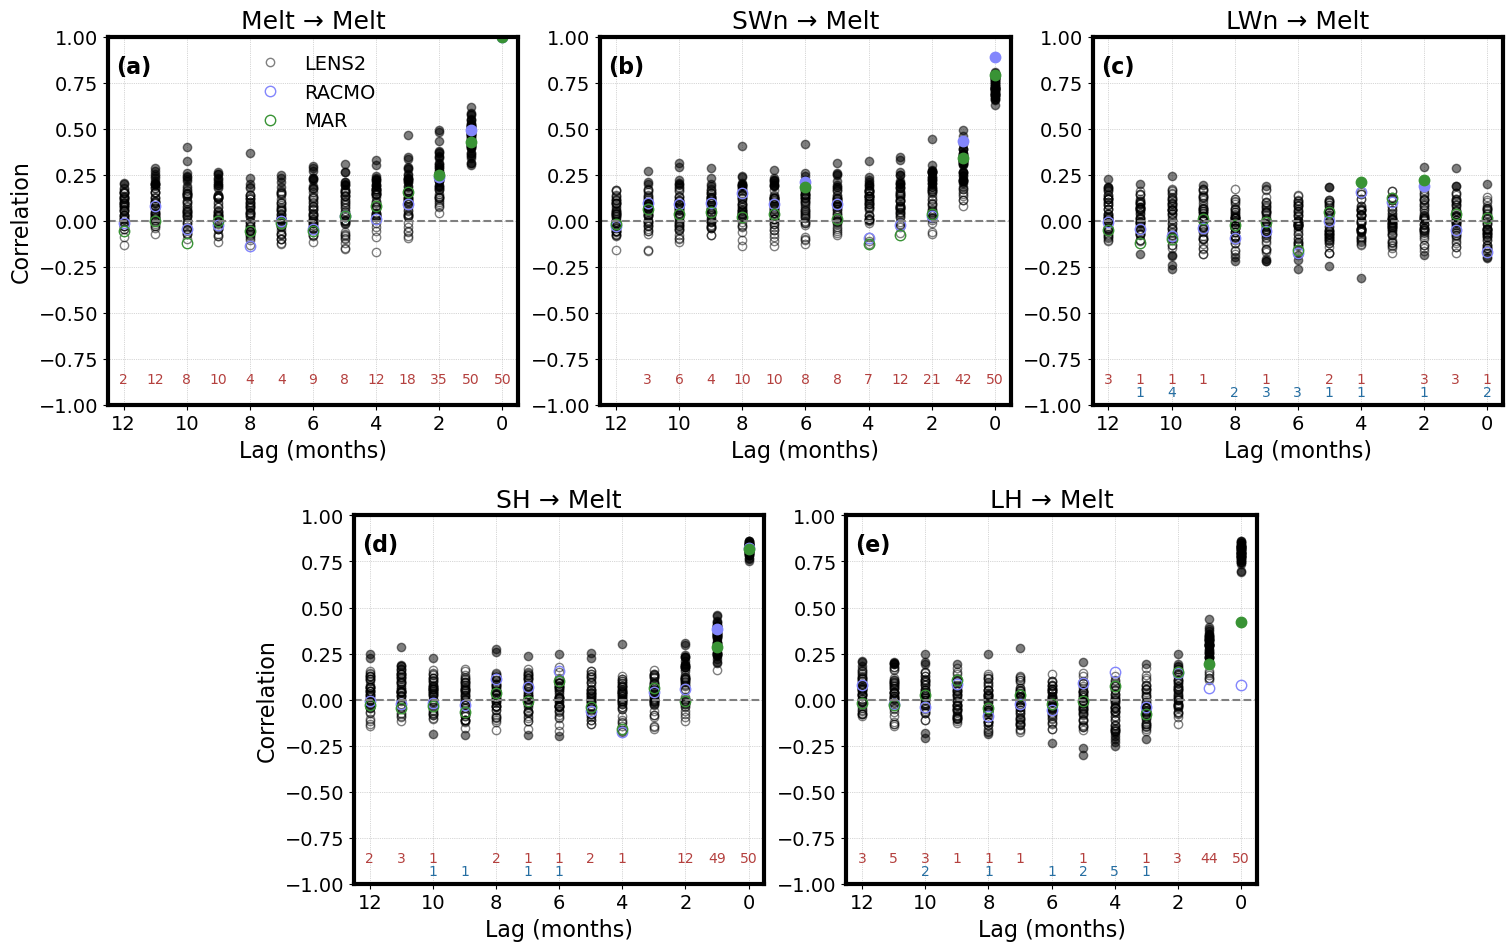

In [20]:
## Remove monthly trend
# Remove the right half of each panel
# Plot in 2 lines
import numpy as np
from scipy.stats import pearsonr
import matplotlib.gridspec as gridspec

sig_level = 0.05

# === Plotting ===
fig = plt.figure(figsize=(18, 11))  # Make taller to fit 2 rows
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.3, wspace=0.5)#, height_ratios=[1, 1])

# Create list of axes in desired layout
axs = [
    fig.add_subplot(gs[0, 0:2]),  # Top-left
    fig.add_subplot(gs[0, 2:4]),  # Top-middle
    fig.add_subplot(gs[0, 4:6]),  # Top-right
    fig.add_subplot(gs[1, 1:3]),  # Bottom row, center-left and center column merged
    fig.add_subplot(gs[1, 3:5])   # Bottom-right
]

plt.rcParams["axes.linewidth"] = 3

#colors = {'CESM2-F09': 'black', 'RACMO': '#1F77B4', 'MAR': '#E377C2'}
colors = {'LENS2': 'black', 'RACMO': '#8386fc', 'MAR': '#399335'} #'#ea841e'
size_legend = 14
size_label = 16
size_title = 18
size_tick = 14
size_text = 10

for idx, var in enumerate(variables):
    ax = axs[idx]
    
    for model_name in models.keys():
        data = correlations[model_name][var]
        
        if model_name == 'LENS2':
            # Prepare counters for CESM2-F09 significance summary
            sig_counts_pos = np.zeros(len(lags), dtype=int)
            sig_counts_neg = np.zeros(len(lags), dtype=int)
            
            # CESM2: loop over ensemble members
            for member in range(50):
                member_corrs = []
                member_pvals = []
                for lag_idx, lag in enumerate(lags):
                    melt_i = models[model_name][0][member, :]
                    var_i = models[model_name][variables.index(var)][member, :]
                    melt_JJA, var_shifted = extract_shifted_JJA(melt_i, var_i, lag)
                    if len(melt_JJA) > 3:
                        corr, pval = pearsonr(var_shifted, melt_JJA)
                        member_corrs.append(corr)
                        member_pvals.append(pval)
                        # Count significance
                        if pval < sig_level:
                            if corr > 0:
                                sig_counts_pos[lag_idx] += 1
                            elif corr < 0:
                                sig_counts_neg[lag_idx] += 1
                    else:
                        member_corrs.append(np.nan)
                        member_pvals.append(np.nan)
                
                # plot each member
                for lag_val, corr_val, p_val in zip(lags, member_corrs, member_pvals):
                    plot_label = model_name if member == 0 and lag_val == lags[8] else None
                    if not np.isnan(p_val) and p_val < sig_level:
                        ax.plot(lag_val, corr_val, 'o', color=colors[model_name], markersize=6, alpha=0.5, label=plot_label)
                    else:
                        ax.plot(lag_val, corr_val, 'o', markerfacecolor='none', markeredgecolor=colors[model_name], markersize=6, alpha=0.5, label=plot_label)

        else:
            # RACMO and MAR
            r = np.array(data)
            pvals = []
            for lag_idx, lag in enumerate(lags):
                melt = models[model_name][0]
                var_flux = models[model_name][variables.index(var)]
                melt_JJA, var_shifted = extract_shifted_JJA(melt, var_flux, lag)
                if len(melt_JJA) > 3:
                    _, pval = pearsonr(var_shifted, melt_JJA)
                    pvals.append(pval)
                else:
                    pvals.append(np.nan)
            
            for lag_val, corr_val, p_val in zip(lags, r, pvals):
                plot_label = model_name if lag_val == lags[4] else None
                if not np.isnan(p_val) and p_val < sig_level:
                    ax.plot(lag_val, corr_val, 'o', color=colors[model_name], markersize=7.5, label=plot_label)
                else:
                    ax.plot(lag_val, corr_val, 'o', markerfacecolor='none', markeredgecolor=colors[model_name], markersize=7.5, label=plot_label)

    # === Add CESM2-F09 significance counts: vertical stacking + color ===
    for lag_idx, lag_val in enumerate(lags):
        pos_count = sig_counts_pos[lag_idx]
        neg_count = sig_counts_neg[lag_idx]
        
        if pos_count > 0:
            ax.text(lag_val, -0.9, f'{pos_count}', ha='center', va='bottom',
                    fontsize=size_text, color='#b4403e')
        if neg_count > 0:
            ax.text(lag_val, -0.97, f'{neg_count}', ha='center', va='bottom',
                    fontsize=size_text, color='#256ea2')

    ax.set_title(f'{var} → Melt', size=size_title)
    ax.set_xlabel('Lag (months)', size=size_label)
    if idx == 0 or idx == 3:
        ax.set_ylabel('Correlation', size=size_label)
    ax.axhline(0, color='gray', linestyle='--')
    #ax.axvline(0, color='gray', linestyle='--')
    ax.set_xlim(-12.5, 0.5)
    ax.set_ylim(-1, 1)
    ax.grid(True, linestyle=':', linewidth=0.5)
    ax.tick_params(labelsize=size_tick)
    ax.set_xticks([-12, -10, -8, -6, -4, -2, 0])
    ax.set_xticklabels([12, 10, 8, 6, 4, 2, 0])

# Add subplot label (a)-(e)
panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)']

for idx, var in enumerate(variables):
    ax = axs[idx]

    # [rest of your plotting code...]

    # Add subplot label
    ax.text(0.02, 0.95, panel_labels[idx], transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left')

    # Only add legend in panel (a)
    if idx == 0:
        ax.legend(loc="upper center", frameon=False, prop={"size": size_legend}, ncol=1)

plt.tight_layout()

plt.savefig(
    home_dir + '2023-GrIS-melt-causality/plot/physics/lagged_cor_LENS2_melt_SEB_ICE_hist_1975_2014_anomaly_CI90_sigcount005_2lines_neglag2_rmmontrend.png',
    dpi=600, bbox_inches="tight", facecolor="w", transparent=False,
)